=== EXPLICACIÓN DEL COMPONENTE -np.log(price_ratio) ===

1. CÁLCULO PASO A PASO:
   Usuario dispuesto a pagar mínimo: $20
   Fórmula: -np.log(price / user_min_price)

   Precio: $ 20 | Ratio: 1.00 | log(1.00) = 0.000 | Final: -0.000
   Precio: $ 25 | Ratio: 1.25 | log(1.25) = 0.223 | Final: -0.223
   Precio: $ 30 | Ratio: 1.50 | log(1.50) = 0.405 | Final: -0.405
   Precio: $ 40 | Ratio: 2.00 | log(2.00) = 0.693 | Final: -0.693
   Precio: $ 50 | Ratio: 2.50 | log(2.50) = 0.916 | Final: -0.916
   Precio: $ 60 | Ratio: 3.00 | log(3.00) = 1.099 | Final: -1.099
   Precio: $ 80 | Ratio: 4.00 | log(4.00) = 1.386 | Final: -1.386
   Precio: $100 | Ratio: 5.00 | log(5.00) = 1.609 | Final: -1.609

2. ¿POR QUÉ LOGARITMO NEGATIVO?
   • np.log(1) = 0      → Precio = mínimo del usuario → Score = 0 (neutral)
   • np.log(2) = 0.693  → Precio = 2x mínimo → Score = -0.693 (penalización)
   • np.log(4) = 1.386  → Precio = 4x mínimo → Score = -1.386 (más penalización)
   • np.log(0.5) = -0.693 → Precio = 0

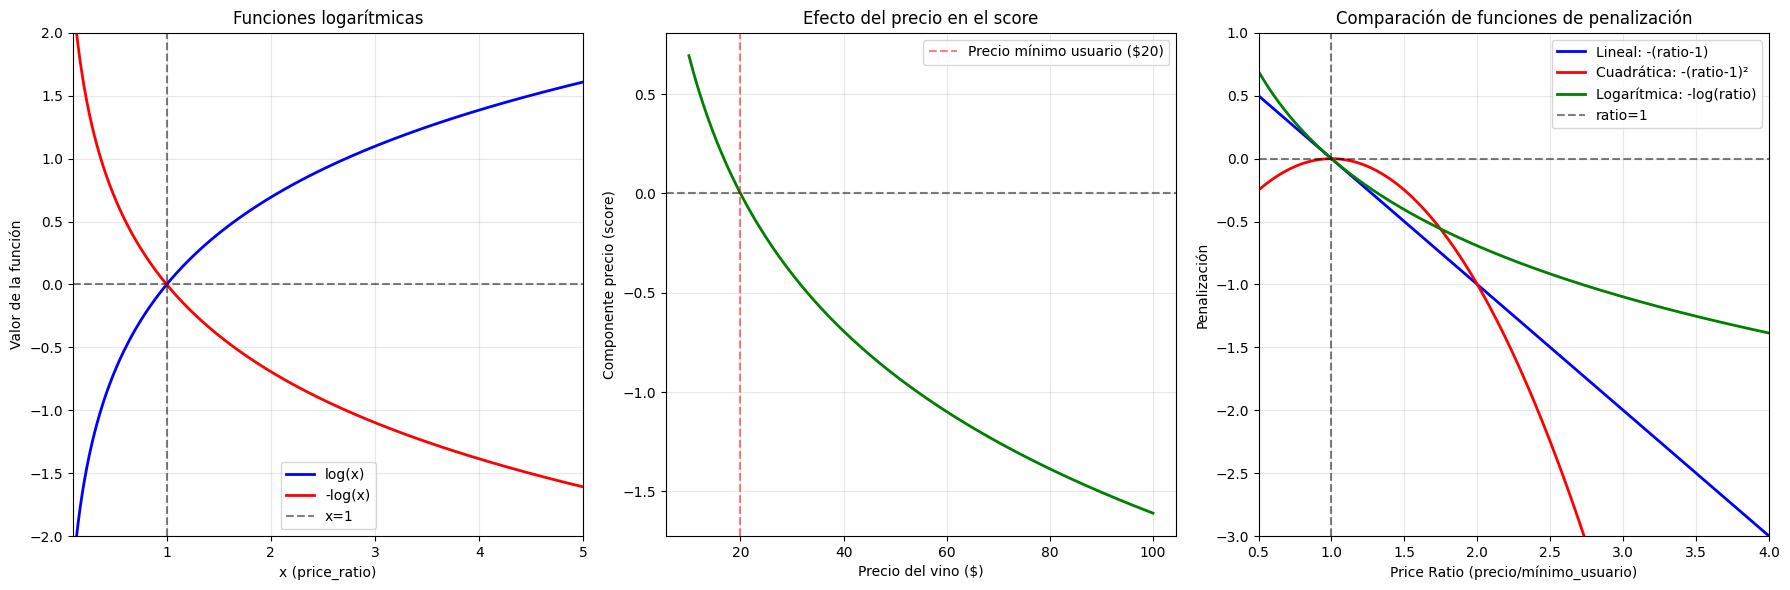


4. VENTAJAS DEL LOGARITMO:
   ✓ Penalización suave: No castiga brutalmente precios altos
   ✓ Realista: Refleja cómo percibimos diferencias de precio
   ✓ Escalable: Funciona bien con cualquier rango de precios
   ✓ Matemáticamente estable: No explota con valores extremos

5. EFECTO DEL PARÁMETRO price_sensitivity:
   • price_sensitivity = 0.5 → Penalización más suave
   • price_sensitivity = 1.0 → Penalización normal
   • price_sensitivity = 2.0 → Penalización más fuerte

6. EJEMPLO CON DIFERENTES SENSIBILIDADES:
   Sensibilidad 0.5: Score = -0.347
   Sensibilidad 1.0: Score = -0.693
   Sensibilidad 1.5: Score = -1.040
   Sensibilidad 2.0: Score = -1.386

=== ¿POR QUÉ LOGARITMO? PERSPECTIVA PSICOLÓGICA ===

1. LEY DE WEBER-FECHNER:
   • Los humanos percibimos diferencias de manera logarítmica
   • $20 → $40 se siente como un salto grande
   • $80 → $100 se siente como un salto pequeño
   • ¡Mismo aumento ($20) pero percepción diferente!

2. EJEMPLOS DE PERCEPCIÓN:
   $10 → $30: Ratio

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def explain_logarithm_component():
    """
    Explica en detalle por qué usamos -np.log(price_ratio) * price_sensitivity
    """
    
    print("=== EXPLICACIÓN DEL COMPONENTE -np.log(price_ratio) ===\n")
    
    # Simular un usuario con precio mínimo de $20
    user_min_price = 20
    
    # Diferentes precios de vinos
    wine_prices = [20, 25, 30, 40, 50, 60, 80, 100]
    
    print("1. CÁLCULO PASO A PASO:")
    print("   Usuario dispuesto a pagar mínimo: $20")
    print("   Fórmula: -np.log(price / user_min_price)\n")
    
    for price in wine_prices:
        price_ratio = price / user_min_price
        log_value = np.log(price_ratio)
        final_component = -log_value
        
        print(f"   Precio: ${price:3d} | Ratio: {price_ratio:.2f} | log({price_ratio:.2f}) = {log_value:.3f} | Final: {final_component:.3f}")
    
    print("\n2. ¿POR QUÉ LOGARITMO NEGATIVO?")
    print("   • np.log(1) = 0      → Precio = mínimo del usuario → Score = 0 (neutral)")
    print("   • np.log(2) = 0.693  → Precio = 2x mínimo → Score = -0.693 (penalización)")
    print("   • np.log(4) = 1.386  → Precio = 4x mínimo → Score = -1.386 (más penalización)")
    print("   • np.log(0.5) = -0.693 → Precio = 0.5x mínimo → Score = +0.693 (¡premio!)")
    
    print("\n3. INTERPRETACIÓN PSICOLÓGICA:")
    print("   • Precio = mínimo usuario: Perfecto, no hay penalización")
    print("   • Precio 2x mayor: Penalización moderada")
    print("   • Precio 4x mayor: Penalización fuerte")
    print("   • La penalización crece más lentamente que el precio (curva logarítmica)")
    
    # Crear visualización
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    
    # Gráfico 1: Función logarítmica básica
    x = np.linspace(0.1, 5, 1000)
    y_log = np.log(x)
    y_neg_log = -np.log(x)
    
    ax1.plot(x, y_log, 'blue', linewidth=2, label='log(x)')
    ax1.plot(x, y_neg_log, 'red', linewidth=2, label='-log(x)')
    ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax1.axvline(x=1, color='k', linestyle='--', alpha=0.5, label='x=1')
    ax1.set_xlabel('x (price_ratio)')
    ax1.set_ylabel('Valor de la función')
    ax1.set_title('Funciones logarítmicas')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0.1, 5)
    ax1.set_ylim(-2, 2)
    
    # Gráfico 2: Efecto en precios reales
    prices_range = np.linspace(10, 100, 200)
    price_ratios = prices_range / user_min_price
    price_components = -np.log(price_ratios)
    
    ax2.plot(prices_range, price_components, 'green', linewidth=2)
    ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax2.axvline(x=user_min_price, color='r', linestyle='--', alpha=0.5, 
                label=f'Precio mínimo usuario (${user_min_price})')
    ax2.set_xlabel('Precio del vino ($)')
    ax2.set_ylabel('Componente precio (score)')
    ax2.set_title('Efecto del precio en el score')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Gráfico 3: Comparación con otras funciones
    price_ratios_comp = np.linspace(0.5, 4, 200)
    
    # Diferentes funciones de penalización
    linear_penalty = -(price_ratios_comp - 1)  # Penalización lineal
    quadratic_penalty = -(price_ratios_comp - 1)**2  # Penalización cuadrática
    log_penalty = -np.log(price_ratios_comp)  # Penalización logarítmica
    
    ax3.plot(price_ratios_comp, linear_penalty, 'blue', linewidth=2, label='Lineal: -(ratio-1)')
    ax3.plot(price_ratios_comp, quadratic_penalty, 'red', linewidth=2, label='Cuadrática: -(ratio-1)²')
    ax3.plot(price_ratios_comp, log_penalty, 'green', linewidth=2, label='Logarítmica: -log(ratio)')
    
    ax3.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax3.axvline(x=1, color='k', linestyle='--', alpha=0.5, label='ratio=1')
    ax3.set_xlabel('Price Ratio (precio/mínimo_usuario)')
    ax3.set_ylabel('Penalización')
    ax3.set_title('Comparación de funciones de penalización')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(0.5, 4)
    ax3.set_ylim(-3, 1)
    
    plt.tight_layout()
    plt.show()
    
    print("\n4. VENTAJAS DEL LOGARITMO:")
    print("   ✓ Penalización suave: No castiga brutalmente precios altos")
    print("   ✓ Realista: Refleja cómo percibimos diferencias de precio")
    print("   ✓ Escalable: Funciona bien con cualquier rango de precios")
    print("   ✓ Matemáticamente estable: No explota con valores extremos")
    
    print("\n5. EFECTO DEL PARÁMETRO price_sensitivity:")
    print("   • price_sensitivity = 0.5 → Penalización más suave")
    print("   • price_sensitivity = 1.0 → Penalización normal")
    print("   • price_sensitivity = 2.0 → Penalización más fuerte")
    
    # Demostrar efecto de price_sensitivity
    print("\n6. EJEMPLO CON DIFERENTES SENSIBILIDADES:")
    test_price = 40  # Precio 2x el mínimo
    for sensitivity in [0.5, 1.0, 1.5, 2.0]:
        ratio = test_price / user_min_price
        component = -np.log(ratio) * sensitivity
        print(f"   Sensibilidad {sensitivity}: Score = {component:.3f}")

def psychological_explanation():
    """
    Explica por qué la función logarítmica modela bien la percepción humana
    """
    print("\n=== ¿POR QUÉ LOGARITMO? PERSPECTIVA PSICOLÓGICA ===")
    
    print("\n1. LEY DE WEBER-FECHNER:")
    print("   • Los humanos percibimos diferencias de manera logarítmica")
    print("   • $20 → $40 se siente como un salto grande")
    print("   • $80 → $100 se siente como un salto pequeño")
    print("   • ¡Mismo aumento ($20) pero percepción diferente!")
    
    print("\n2. EJEMPLOS DE PERCEPCIÓN:")
    base_prices = [10, 20, 50, 100]
    increase = 20
    
    for base in base_prices:
        new_price = base + increase
        ratio_increase = new_price / base
        perceived_impact = np.log(ratio_increase)
        print(f"   ${base} → ${new_price}: Ratio {ratio_increase:.2f}, Impacto percibido: {perceived_impact:.3f}")
    
    print("\n3. APLICACIÓN EN VINOS:")
    print("   • Usuario dispuesto a pagar $25")
    print("   • Vino de $50 (2x): Penalización moderada")
    print("   • Vino de $100 (4x): Penalización fuerte, pero no extrema")
    print("   • Vino de $200 (8x): Penalización muy fuerte")
    print("   • La penalización crece, pero no explota")

# Ejecutar explicaciones
if __name__ == "__main__":
    explain_logarithm_component()
    psychological_explanation()

=== EXPLICACIÓN DE LA FUNCIÓN CUADRÁTICA INVERTIDA ===

1. CONTEXTO DEL EJEMPLO:
   • Precio mínimo usuario: $20
   • Precio máximo usuario: $60
   • Rango de precios: $40
   • Precio ideal (medio): $40.0

2. CÁLCULO PASO A PASO:
   Fórmula: 1 - 4 * (normalized_position - 0.5)²
   Donde: normalized_position = (price - min_price) / price_range

   Precio | Norm_pos | (pos-0.5) | (pos-0.5)² | 4*(pos-0.5)² | Final
   -------|----------|-----------|------------|--------------|-------
   $20    |   0.000  |   -0.500   |   0.250    |    1.000     | +0.000
   $30    |   0.250  |   -0.250   |   0.062    |    0.250     | +0.750
   $40    |   0.500  |   +0.000   |   0.000    |    0.000     | +1.000
   $50    |   0.750  |   +0.250   |   0.062    |    0.250     | +0.750
   $60    |   1.000  |   +0.500   |   0.250    |    1.000     | +0.000

3. ¿POR QUÉ ESTA FORMA?
   • Queremos que el MEDIO del rango tenga el mejor score
   • Los EXTREMOS (min y max) deben tener scores menores
   • La función debe

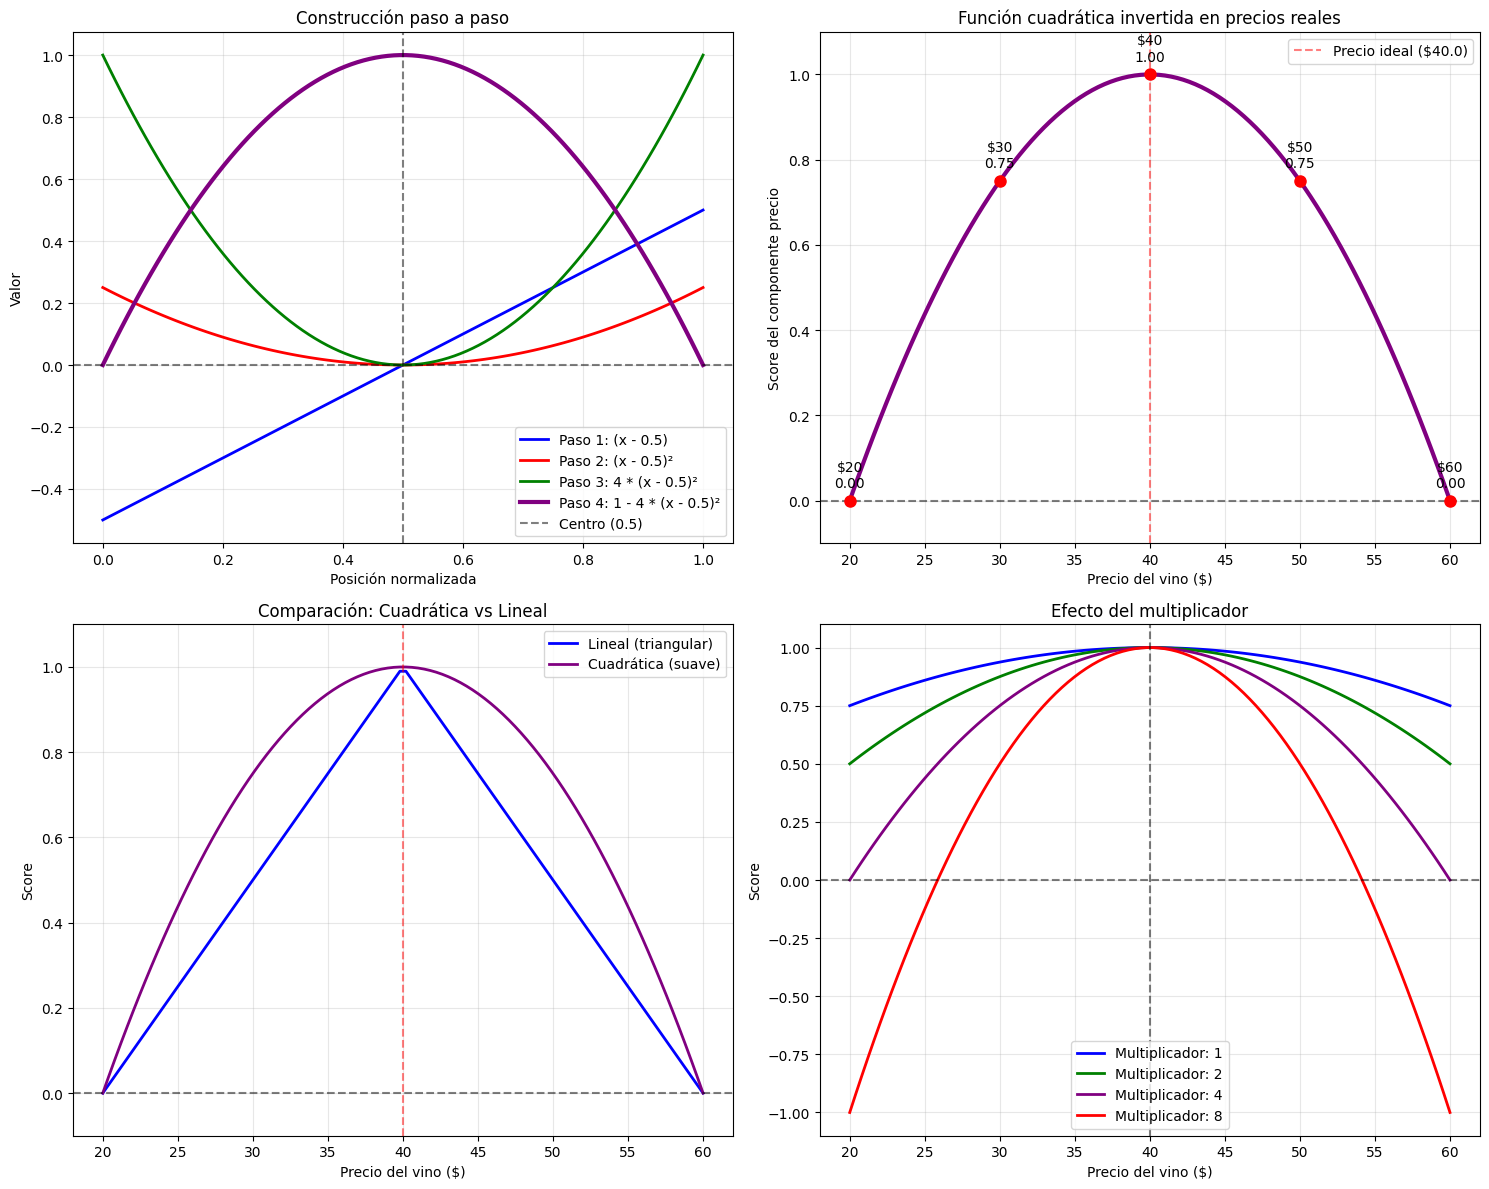


5. VENTAJAS DE ESTA FUNCIÓN:
   ✓ Premia el precio 'justo' (medio del rango)
   ✓ Penaliza suavemente los extremos
   ✓ Simétrica: no discrimina entre 'muy barato' y 'muy caro'
   ✓ Suave: no hay cambios bruscos
   ✓ Escalable: funciona con cualquier rango de precios

6. INTERPRETACIÓN PSICOLÓGICA:
   • Precio muy bajo (min): Puede parecer de mala calidad
   • Precio medio: 'Sweet spot' - buena relación precio-calidad
   • Precio muy alto (max): Caro pero dentro del presupuesto
   • La función refleja que el usuario prefiere el 'punto medio'

=== DETALLES MATEMÁTICOS ===

1. FORMA GENERAL:
   f(x) = 1 - 4 * (x - 0.5)²
   • Tipo: Parábola invertida
   • Vértice: (0.5, 1)
   • Dominio: [0, 1] (posición normalizada)
   • Rango: [0, 1] (para x en [0, 1])

2. DERIVADA (para ver la pendiente):
   f'(x) = -8 * (x - 0.5)
   • En x=0: f'(0) = -8 * (-0.5) = +4 (pendiente positiva)
   • En x=0.5: f'(0.5) = -8 * (0) = 0 (máximo)
   • En x=1: f'(1) = -8 * (0.5) = -4 (pendiente negativa)

3. ¿POR Q

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def explain_quadratic_function():
    """
    Explica en detalle la función cuadrática invertida:
    price_component = 1 - 4 * (normalized_position - 0.5) ** 2
    """
    
    print("=== EXPLICACIÓN DE LA FUNCIÓN CUADRÁTICA INVERTIDA ===\n")
    
    # Ejemplo con rango de precios específico
    user_min_price = 20
    user_max_price = 60
    price_range = user_max_price - user_min_price  # $40
    
    print("1. CONTEXTO DEL EJEMPLO:")
    print(f"   • Precio mínimo usuario: ${user_min_price}")
    print(f"   • Precio máximo usuario: ${user_max_price}")
    print(f"   • Rango de precios: ${price_range}")
    print(f"   • Precio ideal (medio): ${(user_min_price + user_max_price) / 2}")
    
    print("\n2. CÁLCULO PASO A PASO:")
    print("   Fórmula: 1 - 4 * (normalized_position - 0.5)²")
    print("   Donde: normalized_position = (price - min_price) / price_range")
    print()
    
    # Ejemplos específicos
    test_prices = [20, 30, 40, 50, 60]  # Precios de prueba
    
    print("   Precio | Norm_pos | (pos-0.5) | (pos-0.5)² | 4*(pos-0.5)² | Final")
    print("   -------|----------|-----------|------------|--------------|-------")
    
    for price in test_prices:
        normalized_pos = (price - user_min_price) / price_range
        deviation = normalized_pos - 0.5
        squared_dev = deviation ** 2
        penalty = 4 * squared_dev
        final_component = 1 - penalty
        
        print(f"   ${price:2d}    |   {normalized_pos:.3f}  |   {deviation:+.3f}   |   {squared_dev:.3f}    |    {penalty:.3f}     | {final_component:+.3f}")
    
    print("\n3. ¿POR QUÉ ESTA FORMA?")
    print("   • Queremos que el MEDIO del rango tenga el mejor score")
    print("   • Los EXTREMOS (min y max) deben tener scores menores")
    print("   • La función debe ser SIMÉTRICA respecto al centro")
    
    print("\n4. CONSTRUCCIÓN DE LA FUNCIÓN:")
    print("   Paso 1: (normalized_position - 0.5)")
    print("           → Centra la función en 0.5 (medio del rango)")
    print("           → En el medio: (0.5 - 0.5) = 0")
    print("           → En los extremos: (0 - 0.5) = -0.5, (1 - 0.5) = +0.5")
    
    print("\n   Paso 2: (normalized_position - 0.5)²")
    print("           → Hace la función simétrica (elimina signos negativos)")
    print("           → En el medio: 0² = 0")
    print("           → En los extremos: (-0.5)² = 0.25, (+0.5)² = 0.25")
    
    print("\n   Paso 3: 4 * (normalized_position - 0.5)²")
    print("           → Amplifica la penalización en los extremos")
    print("           → En el medio: 4 * 0 = 0")
    print("           → En los extremos: 4 * 0.25 = 1")
    
    print("\n   Paso 4: 1 - 4 * (normalized_position - 0.5)²")
    print("           → Invierte la función (máximo en el centro)")
    print("           → En el medio: 1 - 0 = 1 (máximo score)")
    print("           → En los extremos: 1 - 1 = 0 (mínimo score)")
    
    # Crear visualización
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # Gráfico 1: Función paso a paso
    x = np.linspace(0, 1, 100)  # normalized_position
    
    step1 = x - 0.5
    step2 = (x - 0.5) ** 2
    step3 = 4 * (x - 0.5) ** 2
    step4 = 1 - 4 * (x - 0.5) ** 2
    
    ax1.plot(x, step1, 'blue', linewidth=2, label='Paso 1: (x - 0.5)')
    ax1.plot(x, step2, 'red', linewidth=2, label='Paso 2: (x - 0.5)²')
    ax1.plot(x, step3, 'green', linewidth=2, label='Paso 3: 4 * (x - 0.5)²')
    ax1.plot(x, step4, 'purple', linewidth=3, label='Paso 4: 1 - 4 * (x - 0.5)²')
    
    ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax1.axvline(x=0.5, color='k', linestyle='--', alpha=0.5, label='Centro (0.5)')
    ax1.set_xlabel('Posición normalizada')
    ax1.set_ylabel('Valor')
    ax1.set_title('Construcción paso a paso')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Gráfico 2: Función final con precios reales
    prices = np.linspace(user_min_price, user_max_price, 100)
    normalized_positions = (prices - user_min_price) / price_range
    price_components = 1 - 4 * (normalized_positions - 0.5) ** 2
    
    ax2.plot(prices, price_components, 'purple', linewidth=3)
    ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax2.axvline(x=(user_min_price + user_max_price) / 2, color='r', linestyle='--', alpha=0.5, 
                label=f'Precio ideal (${(user_min_price + user_max_price) / 2})')
    
    # Marcar puntos específicos
    for price in test_prices:
        norm_pos = (price - user_min_price) / price_range
        score = 1 - 4 * (norm_pos - 0.5) ** 2
        ax2.plot(price, score, 'ro', markersize=8)
        ax2.annotate(f'${price}\n{score:.2f}', (price, score), 
                    textcoords="offset points", xytext=(0,10), ha='center')
    
    ax2.set_xlabel('Precio del vino ($)')
    ax2.set_ylabel('Score del componente precio')
    ax2.set_title('Función cuadrática invertida en precios reales')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(-0.1, 1.1)
    
    # Gráfico 3: Comparación con otras funciones
    linear_score = 1 - 2 * np.abs(normalized_positions - 0.5)  # Función triangular
    quadratic_score = 1 - 4 * (normalized_positions - 0.5) ** 2  # Nuestra función
    
    ax3.plot(prices, linear_score, 'blue', linewidth=2, label='Lineal (triangular)')
    ax3.plot(prices, quadratic_score, 'purple', linewidth=2, label='Cuadrática (suave)')
    
    ax3.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax3.axvline(x=(user_min_price + user_max_price) / 2, color='r', linestyle='--', alpha=0.5)
    ax3.set_xlabel('Precio del vino ($)')
    ax3.set_ylabel('Score')
    ax3.set_title('Comparación: Cuadrática vs Lineal')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim(-0.1, 1.1)
    
    # Gráfico 4: Efecto de cambiar el multiplicador
    multipliers = [1, 2, 4, 8]
    colors = ['blue', 'green', 'purple', 'red']
    
    for mult, color in zip(multipliers, colors):
        scores = 1 - mult * (normalized_positions - 0.5) ** 2
        ax4.plot(prices, scores, color=color, linewidth=2, label=f'Multiplicador: {mult}')
    
    ax4.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax4.axvline(x=(user_min_price + user_max_price) / 2, color='k', linestyle='--', alpha=0.5)
    ax4.set_xlabel('Precio del vino ($)')
    ax4.set_ylabel('Score')
    ax4.set_title('Efecto del multiplicador')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n5. VENTAJAS DE ESTA FUNCIÓN:")
    print("   ✓ Premia el precio 'justo' (medio del rango)")
    print("   ✓ Penaliza suavemente los extremos")
    print("   ✓ Simétrica: no discrimina entre 'muy barato' y 'muy caro'")
    print("   ✓ Suave: no hay cambios bruscos")
    print("   ✓ Escalable: funciona con cualquier rango de precios")
    
    print("\n6. INTERPRETACIÓN PSICOLÓGICA:")
    print("   • Precio muy bajo (min): Puede parecer de mala calidad")
    print("   • Precio medio: 'Sweet spot' - buena relación precio-calidad")
    print("   • Precio muy alto (max): Caro pero dentro del presupuesto")
    print("   • La función refleja que el usuario prefiere el 'punto medio'")

def mathematical_details():
    """
    Detalles matemáticos adicionales de la función cuadrática
    """
    print("\n=== DETALLES MATEMÁTICOS ===")
    
    print("\n1. FORMA GENERAL:")
    print("   f(x) = 1 - 4 * (x - 0.5)²")
    print("   • Tipo: Parábola invertida")
    print("   • Vértice: (0.5, 1)")
    print("   • Dominio: [0, 1] (posición normalizada)")
    print("   • Rango: [0, 1] (para x en [0, 1])")
    
    print("\n2. DERIVADA (para ver la pendiente):")
    print("   f'(x) = -8 * (x - 0.5)")
    print("   • En x=0: f'(0) = -8 * (-0.5) = +4 (pendiente positiva)")
    print("   • En x=0.5: f'(0.5) = -8 * (0) = 0 (máximo)")
    print("   • En x=1: f'(1) = -8 * (0.5) = -4 (pendiente negativa)")
    
    print("\n3. ¿POR QUÉ EL MULTIPLICADOR 4?")
    print("   Para que f(0) = f(1) = 0:")
    print("   • f(0) = 1 - multiplicador * (0 - 0.5)² = 1 - multiplicador * 0.25")
    print("   • Para que f(0) = 0: multiplicador * 0.25 = 1 → multiplicador = 4")
    print("   • Así garantizamos que los extremos tengan score 0")
    
    print("\n4. VARIACIONES POSIBLES:")
    print("   • Multiplicador < 4: Los extremos tendrían score > 0")
    print("   • Multiplicador > 4: Los extremos tendrían score < 0 (penalización)")
    print("   • Cambiar 0.5: Mover el punto óptimo hacia un extremo")

# Ejecutar explicaciones
if __name__ == "__main__":
    explain_quadratic_function()
    mathematical_details()

=== FUNCIÓN SIGMOIDE: EXPLICACIÓN COMPLETA ===

1. ¿QUÉ ES LA FUNCIÓN SIGMOIDE?
   • Una función matemática que mapea CUALQUIER número real a un rango [0, 1]
   • Tiene forma de 'S' (por eso se llama sigmoide)
   • Fórmula básica: f(x) = 1 / (1 + e^(-x))
   • Donde 'e' es el número de Euler (~2.718)

2. FÓRMULA PASO A PASO:
   f(x) = 1 / (1 + e^(-x))
   • e^(-x): Exponencial negativa
   • 1 + e^(-x): Suma 1 al exponencial
   • 1 / (1 + e^(-x)): Invierte el resultado

3. COMPORTAMIENTO BÁSICO:
   x    | e^(-x) | 1+e^(-x) | 1/(1+e^(-x)) | Resultado
   -----|--------|----------|--------------|----------
   -5   | 148.413 |  149.413 |       0.007 | 0.007
   -2   |  7.389 |    8.389 |       0.119 | 0.119
   -1   |  2.718 |    3.718 |       0.269 | 0.269
    0   |  1.000 |    2.000 |       0.500 | 0.500
    1   |  0.368 |    1.368 |       0.731 | 0.731
    2   |  0.135 |    1.135 |       0.881 | 0.881
    5   |  0.007 |    1.007 |       0.993 | 0.993

4. PUNTOS CLAVE:
   • Cuando x → -∞: f(x

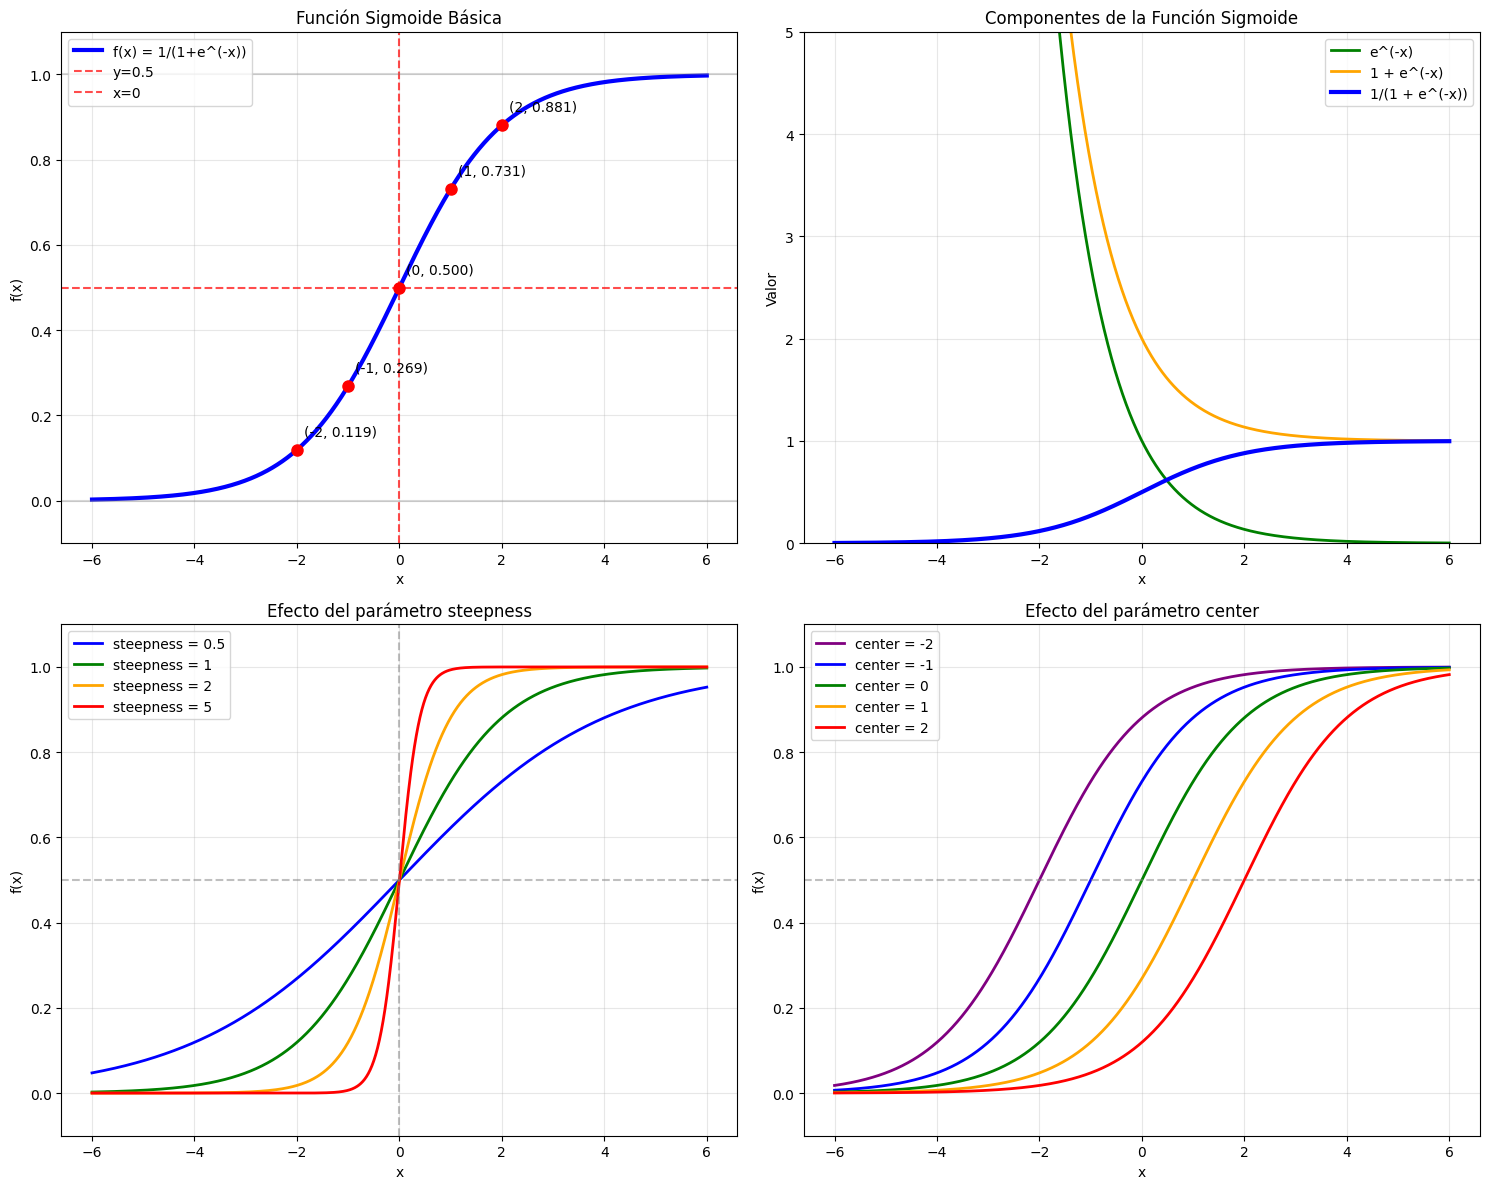


5. VERSIÓN GENERALIZADA:
   f(x) = 1 / (1 + e^(-steepness * (x - center)))
   • center: Dónde está el punto x=0.5
   • steepness: Qué tan empinada es la curva

6. CASOS PRÁCTICOS:
   • steepness = 0.5: Curva muy suave
   • steepness = 1: Curva normal
   • steepness = 5: Curva muy empinada (casi escalón)
   • center = 0: Punto medio en x=0
   • center = 2: Punto medio en x=2

=== APLICACIONES PRÁCTICAS DE LA SIGMOIDE ===

1. EN MACHINE LEARNING:
   • Regresión logística: Para convertir cualquier valor a probabilidad
   • Redes neuronales: Como función de activación
   • Clasificación binaria: Para obtener probabilidades [0,1]

2. EN TU PROBLEMA DE VINOS:
   • Convertir score de precio-calidad a escala [0,1]
   • Normalizar user similarity sin data leakage
   • Convertir cualquier métrica a escala uniforme

3. EJEMPLO CONCRETO - NORMALIZAR TU PRICE-QUALITY:
   Score original | Sigmoide básica | Sigmoide ajustada
   ---------------|-----------------|------------------
           -2.5 |  

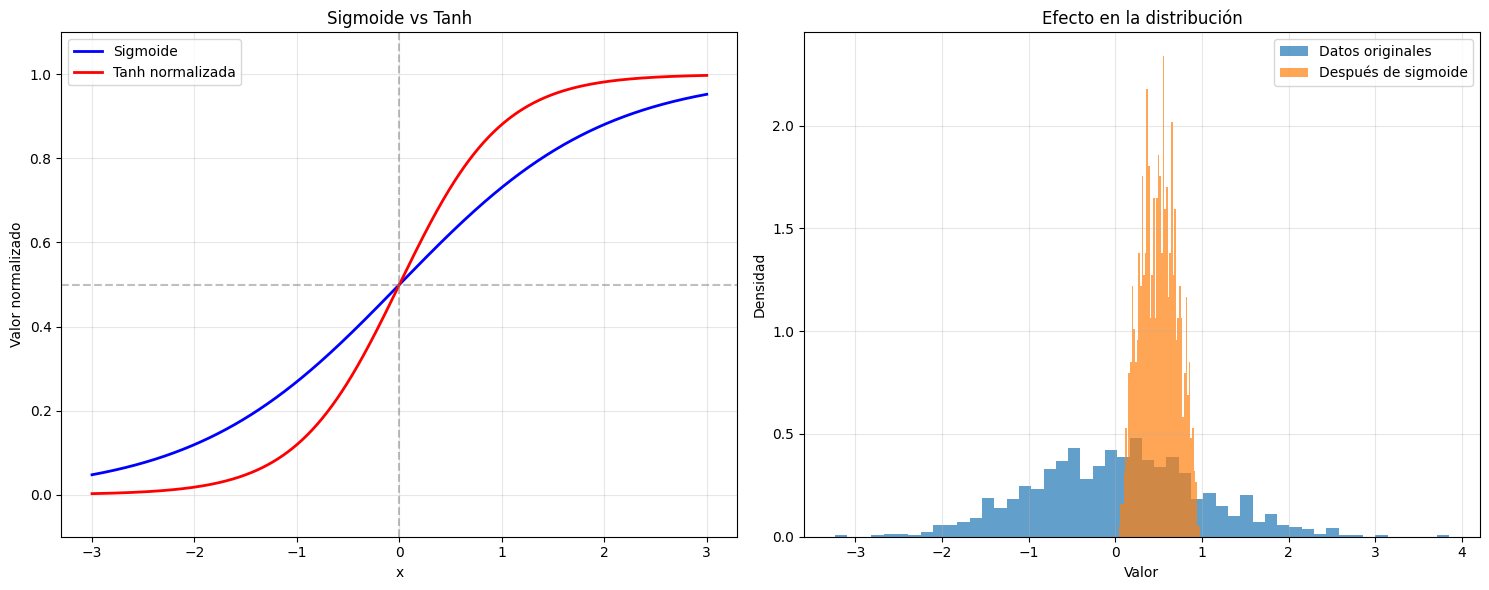

COMPARACIÓN:
   Sigmoide:
   ✓ Suave y derivable
   ✓ Maneja outliers bien
   ✗ Puede saturar extremos
   ✗ Menos intuitiva

   Min-Max scaling:
   ✓ Intuitiva
   ✓ Preserva distribución relativa
   ✗ DATA LEAKAGE (usa min/max del dataset)
   ✗ Sensible a outliers

   Clipping:
   ✓ Simple
   ✓ No data leakage
   ✗ Pierde información
   ✗ Discontinua

=== IMPLEMENTACIÓN PRÁCTICA PARA VINOS ===

EJEMPLO DE USO EN TU WINE SCORING:

1. PRECIO-CALIDAD:
   Score original | Sigmoide normalizada
   ---------------|---------------------
           -2.0 |               0.119
           -1.0 |               0.269
            0.0 |               0.500
            1.0 |               0.731
            2.0 |               0.881

2. USER SIMILARITY (suponiendo que va de 0 a 1):
   • Si ya está en [0,1], no necesita sigmoide
   • Si puede ser negativa, usar sigmoide

3. RATING QUANTITY (popularidad):
   • Mejor usar thresholds fijos para evitar data leakage
   • Ejemplo: <10 qty → 0.2, <50 qty → 0.5,

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid_complete_explanation():
    """
    Explicación completa de la función sigmoide desde cero
    """
    
    print("=== FUNCIÓN SIGMOIDE: EXPLICACIÓN COMPLETA ===\n")
    
    print("1. ¿QUÉ ES LA FUNCIÓN SIGMOIDE?")
    print("   • Una función matemática que mapea CUALQUIER número real a un rango [0, 1]")
    print("   • Tiene forma de 'S' (por eso se llama sigmoide)")
    print("   • Fórmula básica: f(x) = 1 / (1 + e^(-x))")
    print("   • Donde 'e' es el número de Euler (~2.718)")
    
    print("\n2. FÓRMULA PASO A PASO:")
    print("   f(x) = 1 / (1 + e^(-x))")
    print("   • e^(-x): Exponencial negativa")
    print("   • 1 + e^(-x): Suma 1 al exponencial")
    print("   • 1 / (1 + e^(-x)): Invierte el resultado")
    
    print("\n3. COMPORTAMIENTO BÁSICO:")
    
    # Calcular algunos valores de ejemplo
    test_values = [-5, -2, -1, 0, 1, 2, 5]
    print("   x    | e^(-x) | 1+e^(-x) | 1/(1+e^(-x)) | Resultado")
    print("   -----|--------|----------|--------------|----------")
    
    for x in test_values:
        exp_neg_x = np.exp(-x)
        denominator = 1 + exp_neg_x
        result = 1 / denominator
        print(f"   {x:2d}   | {exp_neg_x:6.3f} | {denominator:8.3f} | {result:11.3f} | {result:.3f}")
    
    print("\n4. PUNTOS CLAVE:")
    print("   • Cuando x → -∞: f(x) → 0")
    print("   • Cuando x = 0: f(x) = 0.5")
    print("   • Cuando x → +∞: f(x) → 1")
    print("   • La función NUNCA llega exactamente a 0 o 1")
    print("   • Es SIEMPRE creciente (monótona)")
    
    # Visualización básica
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # Gráfico 1: Función sigmoide básica
    x = np.linspace(-6, 6, 1000)
    y = 1 / (1 + np.exp(-x))
    
    ax1.plot(x, y, 'blue', linewidth=3, label='f(x) = 1/(1+e^(-x))')
    ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='y=0.5')
    ax1.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='x=0')
    ax1.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
    ax1.axhline(y=1, color='gray', linestyle='-', alpha=0.3)
    
    # Marcar puntos importantes
    important_points = [-2, -1, 0, 1, 2]
    for point in important_points:
        y_val = 1 / (1 + np.exp(-point))
        ax1.plot(point, y_val, 'ro', markersize=8)
        ax1.annotate(f'({point}, {y_val:.3f})', (point, y_val), 
                    textcoords="offset points", xytext=(5,10), ha='left')
    
    ax1.set_xlabel('x')
    ax1.set_ylabel('f(x)')
    ax1.set_title('Función Sigmoide Básica')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(-0.1, 1.1)
    
    # Gráfico 2: Componentes de la función
    exp_neg_x = np.exp(-x)
    denominator = 1 + exp_neg_x
    
    ax2.plot(x, exp_neg_x, 'green', linewidth=2, label='e^(-x)')
    ax2.plot(x, denominator, 'orange', linewidth=2, label='1 + e^(-x)')
    ax2.plot(x, y, 'blue', linewidth=3, label='1/(1 + e^(-x))')
    
    ax2.set_xlabel('x')
    ax2.set_ylabel('Valor')
    ax2.set_title('Componentes de la Función Sigmoide')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 5)
    
    # Gráfico 3: Función sigmoide con diferentes steepness
    steepness_values = [0.5, 1, 2, 5]
    colors = ['blue', 'green', 'orange', 'red']
    
    for steep, color in zip(steepness_values, colors):
        y_steep = 1 / (1 + np.exp(-steep * x))
        ax3.plot(x, y_steep, color=color, linewidth=2, label=f'steepness = {steep}')
    
    ax3.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    ax3.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax3.set_xlabel('x')
    ax3.set_ylabel('f(x)')
    ax3.set_title('Efecto del parámetro steepness')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim(-0.1, 1.1)
    
    # Gráfico 4: Función sigmoide con diferentes centros
    centers = [-2, -1, 0, 1, 2]
    colors = ['purple', 'blue', 'green', 'orange', 'red']
    
    for center, color in zip(centers, colors):
        y_center = 1 / (1 + np.exp(-(x - center)))
        ax4.plot(x, y_center, color=color, linewidth=2, label=f'center = {center}')
    
    ax4.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    ax4.set_xlabel('x')
    ax4.set_ylabel('f(x)')
    ax4.set_title('Efecto del parámetro center')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    ax4.set_ylim(-0.1, 1.1)
    
    plt.tight_layout()
    plt.show()
    
    print("\n5. VERSIÓN GENERALIZADA:")
    print("   f(x) = 1 / (1 + e^(-steepness * (x - center)))")
    print("   • center: Dónde está el punto x=0.5")
    print("   • steepness: Qué tan empinada es la curva")
    
    print("\n6. CASOS PRÁCTICOS:")
    print("   • steepness = 0.5: Curva muy suave")
    print("   • steepness = 1: Curva normal")
    print("   • steepness = 5: Curva muy empinada (casi escalón)")
    print("   • center = 0: Punto medio en x=0")
    print("   • center = 2: Punto medio en x=2")

def sigmoid_applications():
    """
    Aplicaciones prácticas de la función sigmoide
    """
    
    print("\n=== APLICACIONES PRÁCTICAS DE LA SIGMOIDE ===\n")
    
    print("1. EN MACHINE LEARNING:")
    print("   • Regresión logística: Para convertir cualquier valor a probabilidad")
    print("   • Redes neuronales: Como función de activación")
    print("   • Clasificación binaria: Para obtener probabilidades [0,1]")
    
    print("\n2. EN TU PROBLEMA DE VINOS:")
    print("   • Convertir score de precio-calidad a escala [0,1]")
    print("   • Normalizar user similarity sin data leakage")
    print("   • Convertir cualquier métrica a escala uniforme")
    
    print("\n3. EJEMPLO CONCRETO - NORMALIZAR TU PRICE-QUALITY:")
    
    # Simular algunos scores de precio-calidad
    price_quality_scores = [-2.5, -1.5, -0.5, 0, 0.5, 1.5, 2.5]
    
    print("   Score original | Sigmoide básica | Sigmoide ajustada")
    print("   ---------------|-----------------|------------------")
    
    for score in price_quality_scores:
        basic_sigmoid = 1 / (1 + np.exp(-score))
        adjusted_sigmoid = 1 / (1 + np.exp(-2 * score))  # steepness = 2
        print(f"   {score:12.1f} | {basic_sigmoid:14.3f} | {adjusted_sigmoid:16.3f}")
    
    print("\n4. VENTAJAS DE LA SIGMOIDE:")
    print("   ✓ Mapea CUALQUIER valor real a [0,1]")
    print("   ✓ Función suave (derivable)")
    print("   ✓ Preserva el orden (monótona creciente)")
    print("   ✓ No requiere conocer min/max del dataset")
    print("   ✓ Maneja outliers gracefully")
    
    print("\n5. DESVENTAJAS:")
    print("   ✗ No es intuitiva para interpretar")
    print("   ✗ Puede 'saturar' valores extremos")
    print("   ✗ Requiere ajustar parámetros (center, steepness)")

def sigmoid_vs_alternatives():
    """
    Comparación de sigmoide con otras funciones de normalización
    """
    
    print("\n=== SIGMOIDE VS OTRAS OPCIONES ===\n")
    
    # Datos de ejemplo
    x = np.linspace(-3, 3, 1000)
    
    # Diferentes funciones de normalización
    sigmoid_norm = 1 / (1 + np.exp(-x))
    tanh_norm = (np.tanh(x) + 1) / 2  # tanh normalizada a [0,1]
    
    # Min-max sería: (x - min(x)) / (max(x) - min(x)) pero tiene data leakage
    # Clipping sería: np.clip(x, 0, 1) pero corta información
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Comparación de funciones
    ax1.plot(x, sigmoid_norm, 'blue', linewidth=2, label='Sigmoide')
    ax1.plot(x, tanh_norm, 'red', linewidth=2, label='Tanh normalizada')
    ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    
    ax1.set_xlabel('x')
    ax1.set_ylabel('Valor normalizado')
    ax1.set_title('Sigmoide vs Tanh')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(-0.1, 1.1)
    
    # Efecto en distribución
    np.random.seed(42)
    data = np.random.normal(0, 1, 1000)  # Datos con media 0, std 1
    
    sigmoid_data = 1 / (1 + np.exp(-data))
    
    ax2.hist(data, bins=50, alpha=0.7, label='Datos originales', density=True)
    ax2.hist(sigmoid_data, bins=50, alpha=0.7, label='Después de sigmoide', density=True)
    
    ax2.set_xlabel('Valor')
    ax2.set_ylabel('Densidad')
    ax2.set_title('Efecto en la distribución')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("COMPARACIÓN:")
    print("   Sigmoide:")
    print("   ✓ Suave y derivable")
    print("   ✓ Maneja outliers bien")
    print("   ✗ Puede saturar extremos")
    print("   ✗ Menos intuitiva")
    
    print("\n   Min-Max scaling:")
    print("   ✓ Intuitiva")
    print("   ✓ Preserva distribución relativa")
    print("   ✗ DATA LEAKAGE (usa min/max del dataset)")
    print("   ✗ Sensible a outliers")
    
    print("\n   Clipping:")
    print("   ✓ Simple")
    print("   ✓ No data leakage")
    print("   ✗ Pierde información")
    print("   ✗ Discontinua")

def practical_sigmoid_for_wine_scoring():
    """
    Implementación práctica para el problema de scoring de vinos
    """
    
    print("\n=== IMPLEMENTACIÓN PRÁCTICA PARA VINOS ===\n")
    
    def sigmoid(x, center=0, steepness=1):
        """
        Función sigmoide generalizada
        
        Args:
            x: valor a normalizar
            center: punto donde f(x) = 0.5
            steepness: qué tan empinada es la curva
        """
        return 1 / (1 + np.exp(-steepness * (x - center)))
    
    # Ejemplo para diferentes componentes
    print("EJEMPLO DE USO EN TU WINE SCORING:")
    print()
    
    # 1. Precio-calidad score
    price_quality_scores = [-2, -1, 0, 1, 2]
    print("1. PRECIO-CALIDAD:")
    print("   Score original | Sigmoide normalizada")
    print("   ---------------|---------------------")
    
    for score in price_quality_scores:
        normalized = sigmoid(score, center=0, steepness=1)
        print(f"   {score:12.1f} | {normalized:19.3f}")
    
    print("\n2. USER SIMILARITY (suponiendo que va de 0 a 1):")
    print("   • Si ya está en [0,1], no necesita sigmoide")
    print("   • Si puede ser negativa, usar sigmoide")
    
    print("\n3. RATING QUANTITY (popularidad):")
    print("   • Mejor usar thresholds fijos para evitar data leakage")
    print("   • Ejemplo: <10 qty → 0.2, <50 qty → 0.5, <200 qty → 0.8, >200 qty → 1.0")
    
    print("\n4. CÓDIGO FINAL SUGERIDO:")
    print("""
    def normalize_component(value, method='sigmoid', **kwargs):
        if method == 'sigmoid':
            center = kwargs.get('center', 0)
            steepness = kwargs.get('steepness', 1)
            return 1 / (1 + np.exp(-steepness * (value - center)))
        elif method == 'fixed_thresholds':
            thresholds = kwargs.get('thresholds', [])
            # Implementar lógica de thresholds
            pass
        # Otros métodos...
    
    # Uso:
    wine_score = (
        rating_w * (rating / 5) + 
        price_quality_w * normalize_component(price_quality_score, 'sigmoid', center=0, steepness=1) + 
        rating_qty_w * normalize_component(rating_qty, 'fixed_thresholds', thresholds=[10, 50, 200]) +
        user_similarity_w * user_similarity + 
        main_pairing_w * main_pairing_score
    )
    """)

# Ejecutar todas las explicaciones
if __name__ == "__main__":
    sigmoid_complete_explanation()
    sigmoid_applications()
    sigmoid_vs_alternatives()
    practical_sigmoid_for_wine_scoring()
    
    print("\n=== MATERIAL PARA SEGUIR INVESTIGANDO ===")
    print("\n1. CONCEPTOS RELACIONADOS:")
    print("   • Función logística (es lo mismo que sigmoide)")
    print("   • Regresión logística")
    print("   • Funciones de activación en redes neuronales")
    print("   • Transformaciones no lineales")
    
    print("\n2. BÚSQUEDAS RECOMENDADAS:")
    print("   • 'sigmoid function machine learning'")
    print("   • 'logistic function normalization'")
    print("   • 'feature scaling without data leakage'")
    print("   • 'activation functions comparison'")
    
    print("\n3. RECURSOS MATEMÁTICOS:")
    print("   • Khan Academy: Exponential functions")
    print("   • 3Blue1Brown: Neural Networks series")
    print("   • Coursera: Machine Learning Course (Andrew Ng)")
    print("   • Wikipedia: Logistic function")
    
    print("\n4. TÉRMINOS CLAVE:")
    print("   • Monotonic function (función monótona)")
    print("   • Saturation (saturación)")
    print("   • Logit (inversa de sigmoide)")
    print("   • Activation function (función de activación)")

In [4]:
import numpy as np
import pandas as pd
from typing import Dict, Union

class WineSimilarityCalculator:
    def __init__(self, taste_cols):
        self.taste_cols = taste_cols
    
    def _df_add_user_similarity(self, df: pd.DataFrame, tastes: Dict) -> pd.DataFrame:
        """
        Agrega columna de similitud con el input del usuario al df.
        Mantiene fuzzy distance original pero convierte a similitud sin data leakage.
        """
        tra_df = df.copy()
        
        # Calcula distancias fuzzy (tu función original)
        distances = self._compute_fuzzy_distance(tra_df[self.taste_cols], tastes)
        
        # Convierte a similitud sin escalado (varias opciones)
        # Opción 1: Similitud exponencial (recomendada)
        tra_df["user_similarity"] = self._distance_to_similarity_exponential(distances)
        
        # Opción 2: Similitud inversa suave
        # tra_df["user_similarity"] = self._distance_to_similarity_inverse(distances)
        
        # Opción 3: Similitud sigmoidea
        # tra_df["user_similarity"] = self._distance_to_similarity_sigmoid(distances)
        
        tra_df["taste_distance_raw"] = distances
        return tra_df
    
    def _compute_fuzzy_distance(self, tastes_df: pd.DataFrame, tastes: Dict) -> np.array:
        """
        Tu función original de fuzzy distance - SIN CAMBIOS
        """
        distances = []
        for _, row in tastes_df.iterrows():
            wine_distance = 0
            col_count = 0
            for col_name in tastes_df.columns:
                if col_name in tastes:
                    value = row[col_name]
                    q_low, q_high = tastes[col_name]
                    wine_distance += self._fuzzy_distance(value, q_low, q_high)
                    col_count += 1
            
            distance = wine_distance / col_count if col_count > 0 else None
            distances.append(distance)

        distances = np.array(distances)
        return distances
    
    def _fuzzy_distance(self, value: Union[float, int], q_low: Union[float, int], q_high: Union[float, int]) -> Union[float, int]:
        """
        Tu función original de fuzzy distance - SIN CAMBIOS
        """
        if value < q_low:
            return (q_low - value) / (q_high - q_low)
        elif value > q_high:
            return (value - q_high) / (q_high - q_low)
        else:
            return 0.0
    
    # ========== OPCIONES PARA CONVERTIR DISTANCIA A SIMILITUD ==========
    
    def _distance_to_similarity_exponential(self, distances: np.array, decay_factor: float = 2.0) -> np.array:
        """
        Opción 1: Similitud exponencial (RECOMENDADA)
        
        - Cuando distancia = 0 → similitud = 1.0
        - Cuando distancia = 1 → similitud ≈ 0.135 (con decay=2)
        - Cuando distancia = 2 → similitud ≈ 0.018
        - Siempre entre 0 y 1, sin data leakage
        
        Args:
            decay_factor: Mayor valor = más penalización por distancia
                         - 1.0: Permisivo (dist=1 → sim=0.37)
                         - 2.0: Estándar (dist=1 → sim=0.14)
                         - 3.0: Estricto (dist=1 → sim=0.05)
        """
        return np.exp(-decay_factor * distances)
    
    def _distance_to_similarity_inverse(self, distances: np.array, smoothing: float = 1.0) -> np.array:
        """
        Opción 2: Similitud inversa suave
        
        - Cuando distancia = 0 → similitud = 1.0
        - Cuando distancia = 1 → similitud = 0.5 (con smoothing=1)
        - Cuando distancia = 2 → similitud = 0.33
        - Decaimiento más gradual que exponencial
        
        Args:
            smoothing: Controla suavidad de la curva
                      - 0.5: Más abrupta
                      - 1.0: Estándar
                      - 2.0: Más suave
        """
        return smoothing / (smoothing + distances)
    
    def _distance_to_similarity_sigmoid(self, distances: np.array, steepness: float = 3.0, midpoint: float = 1.0) -> np.array:
        """
        Opción 3: Similitud sigmoidea
        
        - Cuando distancia = 0 → similitud ≈ 0.95
        - Forma de S invertida
        - Útil si quieres transición suave pero definida
        
        Args:
            steepness: Qué tan abrupta es la transición
            midpoint: Punto donde similitud = 0.5
        """
        return 1 / (1 + np.exp(steepness * (distances - midpoint)))
    
    def _distance_to_similarity_linear_capped(self, distances: np.array, max_distance: float = 2.0) -> np.array:
        """
        Opción 4: Similitud lineal con tope
        
        - Cuando distancia = 0 → similitud = 1.0
        - Decaimiento lineal hasta max_distance
        - Cuando distancia >= max_distance → similitud = 0
        
        Args:
            max_distance: Distancia máxima considerada (después = similitud 0)
        """
        similarities = np.maximum(0, 1 - (distances / max_distance))
        return similarities

# Ejemplo comparativo de las diferentes opciones
if __name__ == "__main__":
    # Datos de ejemplo
    taste_cols = ['sweetness', 'acidity', 'tannins']
    
    wines_data = {
        'sweetness': [3.0, 4.5, 2.0, 5.5],  # Uno perfecto, uno límite, uno fuera, uno muy fuera
        'acidity': [4.0, 3.5, 6.0, 2.0],
        'tannins': [3.0, 4.0, 2.0, 1.0]
    }
    df = pd.DataFrame(wines_data)
    
    # Preferencias del usuario
    user_tastes = {
        'sweetness': (3.0, 4.0),
        'acidity': (3.5, 4.5),
        'tannins': (2.5, 3.5)
    }
    
    calculator = WineSimilarityCalculator(taste_cols)
    
    # Calcular distancias originales
    distances = calculator._compute_fuzzy_distance(df[taste_cols], user_tastes)
    
    print("Comparación de métodos de similitud:")
    print("Vino | Distancia | Exponencial | Inversa | Sigmoidea | Lineal")
    print("-" * 65)
    
    for i, dist in enumerate(distances):
        exp_sim = calculator._distance_to_similarity_exponential(np.array([dist]))[0]
        inv_sim = calculator._distance_to_similarity_inverse(np.array([dist]))[0]
        sig_sim = calculator._distance_to_similarity_sigmoid(np.array([dist]))[0]
        lin_sim = calculator._distance_to_similarity_linear_capped(np.array([dist]))[0]
        
        print(f"{i+1:4d} | {dist:8.3f} | {exp_sim:10.3f} | {inv_sim:6.3f} | {sig_sim:8.3f} | {lin_sim:5.3f}")
    
    # Ejemplo con vino perfecto (todos los sabores en rango)
    print("\n" + "="*50)
    print("Ejemplo con vino perfecto (distancia = 0):")
    perfect_distance = 0.0
    print(f"Distancia: {perfect_distance}")
    print(f"Similitud exponencial: {calculator._distance_to_similarity_exponential(np.array([perfect_distance]))[0]:.3f}")
    print(f"Similitud inversa: {calculator._distance_to_similarity_inverse(np.array([perfect_distance]))[0]:.3f}")
    print(f"Similitud sigmoidea: {calculator._distance_to_similarity_sigmoid(np.array([perfect_distance]))[0]:.3f}")
    print(f"Similitud lineal: {calculator._distance_to_similarity_linear_capped(np.array([perfect_distance]))[0]:.3f}")

Comparación de métodos de similitud:
Vino | Distancia | Exponencial | Inversa | Sigmoidea | Lineal
-----------------------------------------------------------------
   1 |    0.000 |      1.000 |  1.000 |    0.953 | 1.000
   2 |    0.333 |      0.513 |  0.750 |    0.881 | 0.833
   3 |    1.000 |      0.135 |  0.500 |    0.500 | 0.500
   4 |    1.500 |      0.050 |  0.400 |    0.182 | 0.250

Ejemplo con vino perfecto (distancia = 0):
Distancia: 0.0
Similitud exponencial: 1.000
Similitud inversa: 1.000
Similitud sigmoidea: 0.953
Similitud lineal: 1.000


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def explain_exponential_similarity():
    """
    Explicación detallada de np.exp(-decay_factor * distances)
    """
    print("="*60)
    print("EXPLICACIÓN DE np.exp(-decay_factor * distances)")
    print("="*60)
    
    print("\n1. ¿QUÉ ES np.exp()?")
    print("-" * 25)
    print("np.exp(x) = e^x, donde e ≈ 2.718 (número de Euler)")
    print("Ejemplos:")
    print(f"  np.exp(0) = {np.exp(0)}")
    print(f"  np.exp(1) = {np.exp(1):.3f}")
    print(f"  np.exp(-1) = {np.exp(-1):.3f}")
    print(f"  np.exp(-2) = {np.exp(-2):.3f}")
    
    print("\n2. ¿POR QUÉ EL SIGNO NEGATIVO?")
    print("-" * 32)
    print("Queremos que:")
    print("  - Distancia BAJA → Similitud ALTA")
    print("  - Distancia ALTA → Similitud BAJA")
    print("\nSin signo negativo:")
    print("  exp(2) = 7.39  ← ¡Distancia alta daría similitud alta! ❌")
    print("\nCon signo negativo:")
    print("  exp(-2) = 0.135 ← Distancia alta da similitud baja ✅")
    
    print("\n3. COMPORTAMIENTO MATEMÁTICO")
    print("-" * 31)
    
    # Crear rangos de distancias para visualizar
    distances = np.linspace(0, 3, 100)
    
    decay_factors = [0.5, 1.0, 2.0, 3.0, 5.0]
    
    print("Valores clave para diferentes decay_factors:")
    print("\nDistancia | Decay=0.5 | Decay=1.0 | Decay=2.0 | Decay=3.0 | Decay=5.0")
    print("-" * 70)
    
    key_distances = [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
    
    for dist in key_distances:
        row = f"{dist:8.1f} |"
        for decay in decay_factors:
            similarity = np.exp(-decay * dist)
            row += f"{similarity:10.3f} |"
        print(row)
    
    print("\n4. INTERPRETACIÓN DEL DECAY_FACTOR")
    print("-" * 37)
    print("decay_factor controla qué tan 'estricto' es el sistema:")
    print("\n• decay_factor BAJO (ej: 0.5):")
    print("  - Más 'permisivo'")
    print("  - Vinos con distancia 2.0 aún tienen similitud 0.368")
    print("  - Decaimiento suave")
    
    print("\n• decay_factor ALTO (ej: 5.0):")
    print("  - Más 'estricto'")
    print("  - Vinos con distancia 1.0 ya tienen similitud muy baja (0.007)")
    print("  - Solo vinos muy similares obtienen scores altos")
    
    print("\n5. EJEMPLOS PRÁCTICOS CON VINOS")
    print("-" * 34)
    
    # Ejemplos con datos reales
    examples = [
        ("Vino perfecto (todos en rango)", 0.0),
        ("Vino casi perfecto", 0.2),
        ("Vino bueno", 0.5),
        ("Vino regular", 1.0),
        ("Vino diferente", 1.5),
        ("Vino muy diferente", 2.0),
        ("Vino completamente diferente", 3.0)
    ]
    
    decay_factor = 2.0  # Valor estándar
    
    print(f"\nUsando decay_factor = {decay_factor}:")
    print("Tipo de vino                    | Distancia | Similitud | Interpretación")
    print("-" * 75)
    
    for description, distance in examples:
        similarity = np.exp(-decay_factor * distance)
        
        if similarity > 0.8:
            interpretation = "Excelente match"
        elif similarity > 0.5:
            interpretation = "Buen match"
        elif similarity > 0.2:
            interpretation = "Match moderado"
        elif similarity > 0.05:
            interpretation = "Match bajo"
        else:
            interpretation = "No es un match"
            
        print(f"{description:30} | {distance:8.1f} | {similarity:8.3f} | {interpretation}")
    
    print("\n6. VENTAJAS DE LA FUNCIÓN EXPONENCIAL")
    print("-" * 40)
    print("✅ Siempre da valores entre 0 y 1")
    print("✅ Distancia 0 → Similitud exactamente 1.0")
    print("✅ No requiere conocer el rango de distancias del dataset")
    print("✅ Sin data leakage")
    print("✅ Comportamiento intuitivo y suave")
    print("✅ Parameterizable (ajustar decay_factor)")
    
    print("\n7. COMPARACIÓN CON TU MÉTODO ANTERIOR")
    print("-" * 41)
    print("Método anterior:")
    print("  similarity = 1 - (distance / max_distance)")
    print("  ❌ Depende de max_distance del dataset → data leakage")
    print("  ❌ Diferentes datasets dan diferentes escalas")
    
    print("\nMétodo exponencial:")
    print("  similarity = exp(-decay_factor * distance)")
    print("  ✅ Independiente del dataset")
    print("  ✅ Misma escala siempre")
    print("  ✅ Consistente en entrenamiento y producción")

def visualize_exponential_similarity():
    """
    Visualización gráfica del comportamiento exponencial
    """
    distances = np.linspace(0, 3, 100)
    decay_factors = [0.5, 1.0, 2.0, 3.0, 5.0]
    
    plt.figure(figsize=(12, 8))
    
    # Gráfico principal
    plt.subplot(2, 2, 1)
    for decay in decay_factors:
        similarities = np.exp(-decay * distances)
        plt.plot(distances, similarities, label=f'decay={decay}', linewidth=2)
    
    plt.xlabel('Distancia Fuzzy')
    plt.ylabel('Similitud')
    plt.title('Similitud Exponencial: exp(-decay * distance)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 3)
    plt.ylim(0, 1)
    
    # Zoom en región crítica
    plt.subplot(2, 2, 2)
    distances_zoom = np.linspace(0, 1.5, 100)
    for decay in [1.0, 2.0, 3.0]:
        similarities = np.exp(-decay * distances_zoom)
        plt.plot(distances_zoom, similarities, label=f'decay={decay}', linewidth=2)
    
    plt.xlabel('Distancia Fuzzy')
    plt.ylabel('Similitud')
    plt.title('Zoom: Región crítica (0-1.5)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Comparación con método lineal
    plt.subplot(2, 2, 3)
    distances_comp = np.linspace(0, 2, 100)
    
    # Exponencial
    exp_sim = np.exp(-2.0 * distances_comp)
    plt.plot(distances_comp, exp_sim, label='Exponencial (decay=2)', linewidth=2)
    
    # Lineal (tu método anterior, asumiendo max_distance=2)
    linear_sim = np.maximum(0, 1 - distances_comp / 2.0)
    plt.plot(distances_comp, linear_sim, label='Lineal (1 - d/max)', linewidth=2, linestyle='--')
    
    plt.xlabel('Distancia Fuzzy')
    plt.ylabel('Similitud')
    plt.title('Comparación: Exponencial vs Lineal')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Distribución de similitudes con datos de ejemplo
    plt.subplot(2, 2, 4)
    np.random.seed(42)
    sample_distances = np.random.exponential(0.8, 1000)  # Distancias simuladas
    sample_similarities = np.exp(-2.0 * sample_distances)
    
    plt.hist(sample_similarities, bins=30, alpha=0.7, edgecolor='black')
    plt.xlabel('Similitud')
    plt.ylabel('Frecuencia')
    plt.title('Distribución de Similitudes\n(con distancias simuladas)')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Ejecutar explicación
    explain_exponential_similarity()
    
    # Si quieres ver los gráficos, descomenta la siguiente línea:
    # visualize_exponential_similarity()
    
    print("\n" + "="*60)
    print("EJEMPLO PRÁCTICO CON TUS DATOS")
    print("="*60)
    
    # Simular algunos vinos con diferentes distancias
    wine_distances = np.array([0.0, 0.3, 0.7, 1.2, 1.8, 2.5])
    wine_names = ["Perfecto", "Excelente", "Bueno", "Regular", "Diferente", "Muy diferente"]
    
    print("\nComparación de decay_factors:")
    print("Vino          | Distancia | Decay=1.0 | Decay=2.0 | Decay=3.0")
    print("-" * 58)
    
    for name, distance in zip(wine_names, wine_distances):
        sim_1 = np.exp(-1.0 * distance)
        sim_2 = np.exp(-2.0 * distance)
        sim_3 = np.exp(-3.0 * distance)
        
        print(f"{name:12} | {distance:8.1f} | {sim_1:8.3f} | {sim_2:8.3f} | {sim_3:8.3f}")
    
    print(f"\n¿Cuál decay_factor elegir?")
    print("• decay=1.0: Más permisivo, vinos 'regulares' aún tienen similitud 0.3")
    print("• decay=2.0: Equilibrado, estándar recomendado")
    print("• decay=3.0: Más estricto, solo vinos muy similares obtienen scores altos")

EXPLICACIÓN DE np.exp(-decay_factor * distances)

1. ¿QUÉ ES np.exp()?
-------------------------
np.exp(x) = e^x, donde e ≈ 2.718 (número de Euler)
Ejemplos:
  np.exp(0) = 1.0
  np.exp(1) = 2.718
  np.exp(-1) = 0.368
  np.exp(-2) = 0.135

2. ¿POR QUÉ EL SIGNO NEGATIVO?
--------------------------------
Queremos que:
  - Distancia BAJA → Similitud ALTA
  - Distancia ALTA → Similitud BAJA

Sin signo negativo:
  exp(2) = 7.39  ← ¡Distancia alta daría similitud alta! ❌

Con signo negativo:
  exp(-2) = 0.135 ← Distancia alta da similitud baja ✅

3. COMPORTAMIENTO MATEMÁTICO
-------------------------------
Valores clave para diferentes decay_factors:

Distancia | Decay=0.5 | Decay=1.0 | Decay=2.0 | Decay=3.0 | Decay=5.0
----------------------------------------------------------------------
     0.0 |     1.000 |     1.000 |     1.000 |     1.000 |     1.000 |
     0.5 |     0.779 |     0.607 |     0.368 |     0.223 |     0.082 |
     1.0 |     0.607 |     0.368 |     0.135 |     0.050 |     0

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def explain_gaussian_fuzzy_distance():
    """
    Explicación detallada del método gaussiano para fuzzy distance
    """
    
    print("EXPLICACIÓN DEL MÉTODO GAUSSIANO")
    print("=" * 50)
    
    # Ejemplo concreto
    q_low = 5.0
    q_high = 5.2  # Rango muy estrecho
    center = (q_low + q_high) / 2
    min_range_threshold = 0.1
    
    print(f"Ejemplo: Rango de usuario [{q_low}, {q_high}]")
    print(f"Centro del rango: {center}")
    print()
    
    # PASO 1: Calcular sigma
    print("PASO 1: Calcular sigma (desviación estándar)")
    print("-" * 40)
    
    raw_range = q_high - q_low
    sigma = max(raw_range, min_range_threshold) / 2
    
    print(f"Rango original: {raw_range}")
    print(f"Rango mínimo (threshold): {min_range_threshold}")
    print(f"Rango efectivo: max({raw_range}, {min_range_threshold}) = {max(raw_range, min_range_threshold)}")
    print(f"Sigma = rango_efectivo / 2 = {sigma}")
    print()
    
    print("¿Por qué dividir por 2?")
    print("- En una gaussiana, ~68% de los valores están dentro de ±1σ del centro")
    print("- Si sigma = rango/2, entonces el rango del usuario cubre ~2σ")
    print("- Esto hace que el rango del usuario sea la zona de 'alta similitud'")
    print()
    
    # PASO 2: Función gaussiana
    print("PASO 2: Función gaussiana")
    print("-" * 40)
    
    # Algunos valores de ejemplo
    test_values = [4.5, 5.0, 5.1, 5.2, 5.5, 6.0]
    
    print("Fórmula gaussiana: exp(-d²/2σ²)")
    print("donde d = |value - center|")
    print()
    
    for value in test_values:
        distance_squared = (value - center) ** 2
        gaussian_similarity = np.exp(-distance_squared / (2 * sigma ** 2))
        fuzzy_distance = 1 - gaussian_similarity
        
        print(f"Valor: {value}")
        print(f"  d² = ({value} - {center})² = {distance_squared}")
        print(f"  exp(-d²/2σ²) = exp(-{distance_squared}/(2×{sigma}²)) = {gaussian_similarity:.4f}")
        print(f"  Fuzzy Distance = 1 - {gaussian_similarity:.4f} = {fuzzy_distance:.4f}")
        print()
    
    # PASO 3: Visualización
    print("PASO 3: ¿Por qué 1 - gaussian_similarity?")
    print("-" * 40)
    print("- exp(-d²/2σ²) da SIMILITUD: 1 cuando d=0, → 0 cuando d→∞")
    print("- Nosotros queremos DISTANCIA: 0 cuando d=0, → 1 cuando d→∞") 
    print("- Por eso hacemos: distancia = 1 - similitud")
    print()
    
    return sigma, center

def visualize_gaussian_distance():
    """
    Visualiza cómo funciona la distancia gaussiana
    """
    
    # Configuración
    q_low, q_high = 5.0, 5.2
    center = (q_low + q_high) / 2
    min_range_threshold = 0.1
    sigma = max(q_high - q_low, min_range_threshold) / 2
    
    # Rango de valores para graficar
    x = np.linspace(3, 8, 1000)
    
    # Calcular similitud gaussiana
    distance_squared = (x - center) ** 2
    gaussian_similarity = np.exp(-distance_squared / (2 * sigma ** 2))
    
    # Calcular distancia fuzzy
    fuzzy_distance = 1 - gaussian_similarity
    
    # Crear gráfico
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
    
    # Gráfico 1: Similitud gaussiana
    ax1.plot(x, gaussian_similarity, 'b-', linewidth=2, label='Similitud Gaussiana')
    ax1.axvspan(q_low, q_high, alpha=0.3, color='green', label='Rango Usuario')
    ax1.axvline(center, color='red', linestyle='--', label='Centro')
    ax1.set_ylabel('Similitud')
    ax1.set_title('Similitud Gaussiana: exp(-d²/2σ²)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(-0.1, 1.1)
    
    # Gráfico 2: Distancia fuzzy
    ax2.plot(x, fuzzy_distance, 'r-', linewidth=2, label='Distancia Fuzzy')
    ax2.axvspan(q_low, q_high, alpha=0.3, color='green', label='Rango Usuario')
    ax2.axvline(center, color='red', linestyle='--', label='Centro')
    ax2.set_xlabel('Valor')
    ax2.set_ylabel('Distancia')
    ax2.set_title('Distancia Fuzzy: 1 - exp(-d²/2σ²)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(-0.1, 1.1)
    
    plt.tight_layout()
    plt.show()
    
    print("CARACTERÍSTICAS CLAVE:")
    print("- En el rango del usuario [5.0, 5.2]: distancia ≈ 0")
    print("- Fuera del rango: distancia crece suavemente hacia 1")
    print("- Nunca excede 1, sin importar qué tan lejos esté el valor")
    print("- La curva es suave (no hay saltos bruscos)")

def compare_methods():
    """
    Compara el método gaussiano con el original
    """
    
    print("COMPARACIÓN: MÉTODO ORIGINAL vs GAUSSIANO")
    print("=" * 50)
    
    # Caso problemático: rango muy estrecho
    q_low, q_high = 5.0, 5.05
    center = (q_low + q_high) / 2
    min_range_threshold = 0.1
    sigma = max(q_high - q_low, min_range_threshold) / 2
    
    test_values = [4.0, 4.5, 5.0, 5.025, 5.05, 5.1, 6.0]
    
    print(f"Rango usuario: [{q_low}, {q_high}] (muy estrecho)")
    print()
    print("Valor    | Original | Gaussiano")
    print("-" * 35)
    
    for value in test_values:
        # Método original
        if value < q_low:
            original_dist = (q_low - value) / (q_high - q_low)
        elif value > q_high:
            original_dist = (value - q_high) / (q_high - q_low)
        else:
            original_dist = 0.0
        
        # Método gaussiano
        if q_low <= value <= q_high:
            gaussian_dist = 0.0
        else:
            distance_squared = (value - center) ** 2
            gaussian_similarity = np.exp(-distance_squared / (2 * sigma ** 2))
            gaussian_dist = 1 - gaussian_similarity
        
        print(f"{value:6.2f}   | {original_dist:8.2f} | {gaussian_dist:8.4f}")
    
    print()
    print("PROBLEMAS DEL MÉTODO ORIGINAL:")
    print("- Valor 4.0: distancia = 20 (¡explosiva!)")
    print("- Valor 6.0: distancia = 19 (¡explosiva!)")
    print()
    print("VENTAJAS DEL MÉTODO GAUSSIANO:")
    print("- Todas las distancias están entre 0 y 1")
    print("- Crecimiento suave y controlado")
    print("- Robusto para rangos estrechos")

if __name__ == "__main__":
    sigma, center = explain_gaussian_fuzzy_distance()
    print()
    compare_methods()
    
    # Descomentar para ver gráficos (requiere matplotlib)
    # visualize_gaussian_distance()

EXPLICACIÓN DEL MÉTODO GAUSSIANO
Ejemplo: Rango de usuario [5.0, 5.2]
Centro del rango: 5.1

PASO 1: Calcular sigma (desviación estándar)
----------------------------------------
Rango original: 0.20000000000000018
Rango mínimo (threshold): 0.1
Rango efectivo: max(0.20000000000000018, 0.1) = 0.20000000000000018
Sigma = rango_efectivo / 2 = 0.10000000000000009

¿Por qué dividir por 2?
- En una gaussiana, ~68% de los valores están dentro de ±1σ del centro
- Si sigma = rango/2, entonces el rango del usuario cubre ~2σ
- Esto hace que el rango del usuario sea la zona de 'alta similitud'

PASO 2: Función gaussiana
----------------------------------------
Fórmula gaussiana: exp(-d²/2σ²)
donde d = |value - center|

Valor: 4.5
  d² = (4.5 - 5.1)² = 0.3599999999999996
  exp(-d²/2σ²) = exp(-0.3599999999999996/(2×0.10000000000000009²)) = 0.0000
  Fuzzy Distance = 1 - 0.0000 = 1.0000

Valor: 5.0
  d² = (5.0 - 5.1)² = 0.009999999999999929
  exp(-d²/2σ²) = exp(-0.009999999999999929/(2×0.1000000000000